In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from importlib.resources import files

from clumppling.utils import get_uniq_lb_sep
from clumppling.plot import plot_membership

import ace_of_clust as aoc

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'wurlitzer', 'infomap', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [2]:
base_dir =  Path("..").resolve()
example_data_dir = base_dir / "examples" / "data" / "pbmc3k"

model_comp_dir = example_data_dir / "comp_models" / f"hvg_hc"
model_comp_output_dir = example_data_dir / "comp_models" / f"hvg_hc_output"

## Load Data

### Load meta data, reference from Scanpy tutorials, etc.

In [3]:
# load UMAP reproduced from Scanpy tutorial
umap_file = example_data_dir / "scanpy_tutorial_umap.txt"
X_umap = np.loadtxt(umap_file, delimiter=" ")
print(f"UMAP shape: {X_umap.shape}")

UMAP shape: (2638, 2)


In [4]:
# load (the one-hot encoded, unaligned) Q matrix and labels reproduced from Scanpy tutorial
ref_origQ_file = example_data_dir / "reference" / "scanpy_tutorial.Q"
refQ_orig = np.loadtxt(ref_origQ_file, delimiter=" ")
print(f"Reference Q shape: {refQ_orig.shape}")
orig_lbs = np.argmax(refQ_orig,axis=1)

Reference Q shape: (2638, 8)


In [5]:
# load the (unaligned) cell type labels from Scanpy tutorial
labels_file = example_data_dir / "scanpy_tutorial_labels.txt"
orig_labels = np.loadtxt(labels_file, dtype=str, delimiter="\t")
print(f"{len(orig_labels)} labels:", orig_labels)

8 labels: ['CD4 T' 'B' 'FCGR3A+Monocytes' 'NK' 'CD8 T' 'CD14+Monocytes'
 'Dendritic Cells' 'Megakaryocytes']


### Load default colors

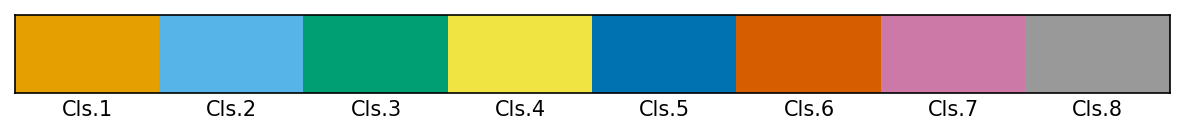

In [6]:
path = files("ace_of_clust").joinpath("resources/default_colors.txt")
text = path.read_text()
default_colors = text.splitlines()
fig, _, _  = aoc.plot_discrete_colorbar(default_colors[:8], K_max=8)

### Load *Clumppling* results

In [7]:
# Load the comparison results
comp_res = aoc.load_compmodels_results(
    res_dir=model_comp_output_dir,
    input_dir=model_comp_dir,
)

# Extract mode-pair mappings across all models
pair_mappings = aoc.get_mode_pair_mappings(
    mode_names=comp_res.full_mode_names,
    all_modes_alignment=comp_res.all_modes_alignment,
    alignment_acrossK=comp_res.alignment_across_all,
)

[load_compmodels_results] Warning: mode_stats file not found for model 'scanpy.tutorial': /oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/pbmc3k/comp_models/hvg_hc/scanpy.tutorial_mode_stats.txt


In [8]:
# print names of all modes
print(f"Loaded {len(comp_res.full_mode_names)} aligned modes from {len(comp_res.models)} models.")
for model in comp_res.models:
    print(f" Model: {model}")
    print("\t", comp_res.modes_by_model[model])

Loaded 16 aligned modes from 5 models.
 Model: scanpy.leiden
	 ['K10M1', 'K10M2', 'K11M1', 'K11M2', 'K12M1']
 Model: scanpy.louvain
	 ['K7M1', 'K7M2', 'K8M1', 'K9M1', 'K9M2', 'K10M1']
 Model: scanpy.tutorial
	 ['scanpy.tutorial']
 Model: seurat.leiden
	 ['K7M1', 'K7M2']
 Model: seurat.louvain
	 ['K9M1', 'K9M2']


#### Plot reference labels (cell types) after alignment

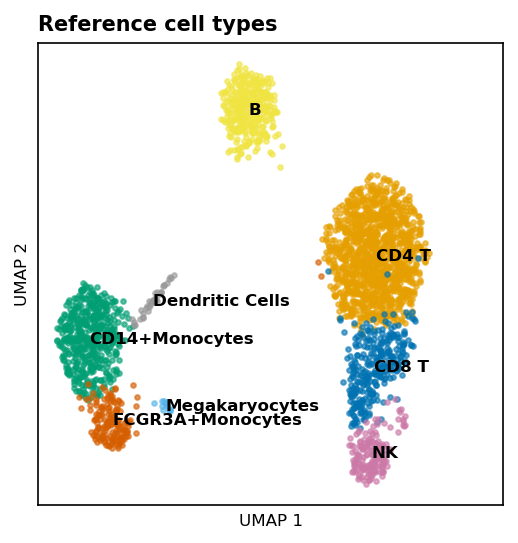

In [9]:
# extract the (aligned) Q matrix and cell types for the Scanpy tutorial mode
refQ = comp_res.Q_by_mode['scanpy.tutorial_scanpy.tutorial']
lbs = np.argmax(refQ,axis=1)
K = refQ.shape[1]
lbs2orig_lbs = dict(zip(lbs,orig_lbs))
labels = [orig_labels[lbs2orig_lbs[lb]] for lb in np.unique(lbs)]

fig, ax = plt.subplots(figsize=(4,4), dpi=150)
for i_cls, cls in enumerate(labels):
    indices = np.where(lbs==i_cls)[0]
    ax.scatter(X_umap[indices,0], X_umap[indices,1], s=5, alpha=0.6, color=default_colors[i_cls])
    ax.text(np.mean(X_umap[indices,0]), np.mean(X_umap[indices,1]), str(cls), fontsize=8, ha='left', va='center', color='black', weight='bold')
ax.set_xlim(-4,18)
ax.set_title("Reference cell types", fontsize=10, ha='left', x=0, weight='bold')
ax.set_xlabel("UMAP 1", fontsize=8)
ax.set_ylabel("UMAP 2", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])
pass


## Visualize and Compare Aligned Clustering Results

### Cluster memberships
#### All modes
Cluster memberships over 2D scatter plot

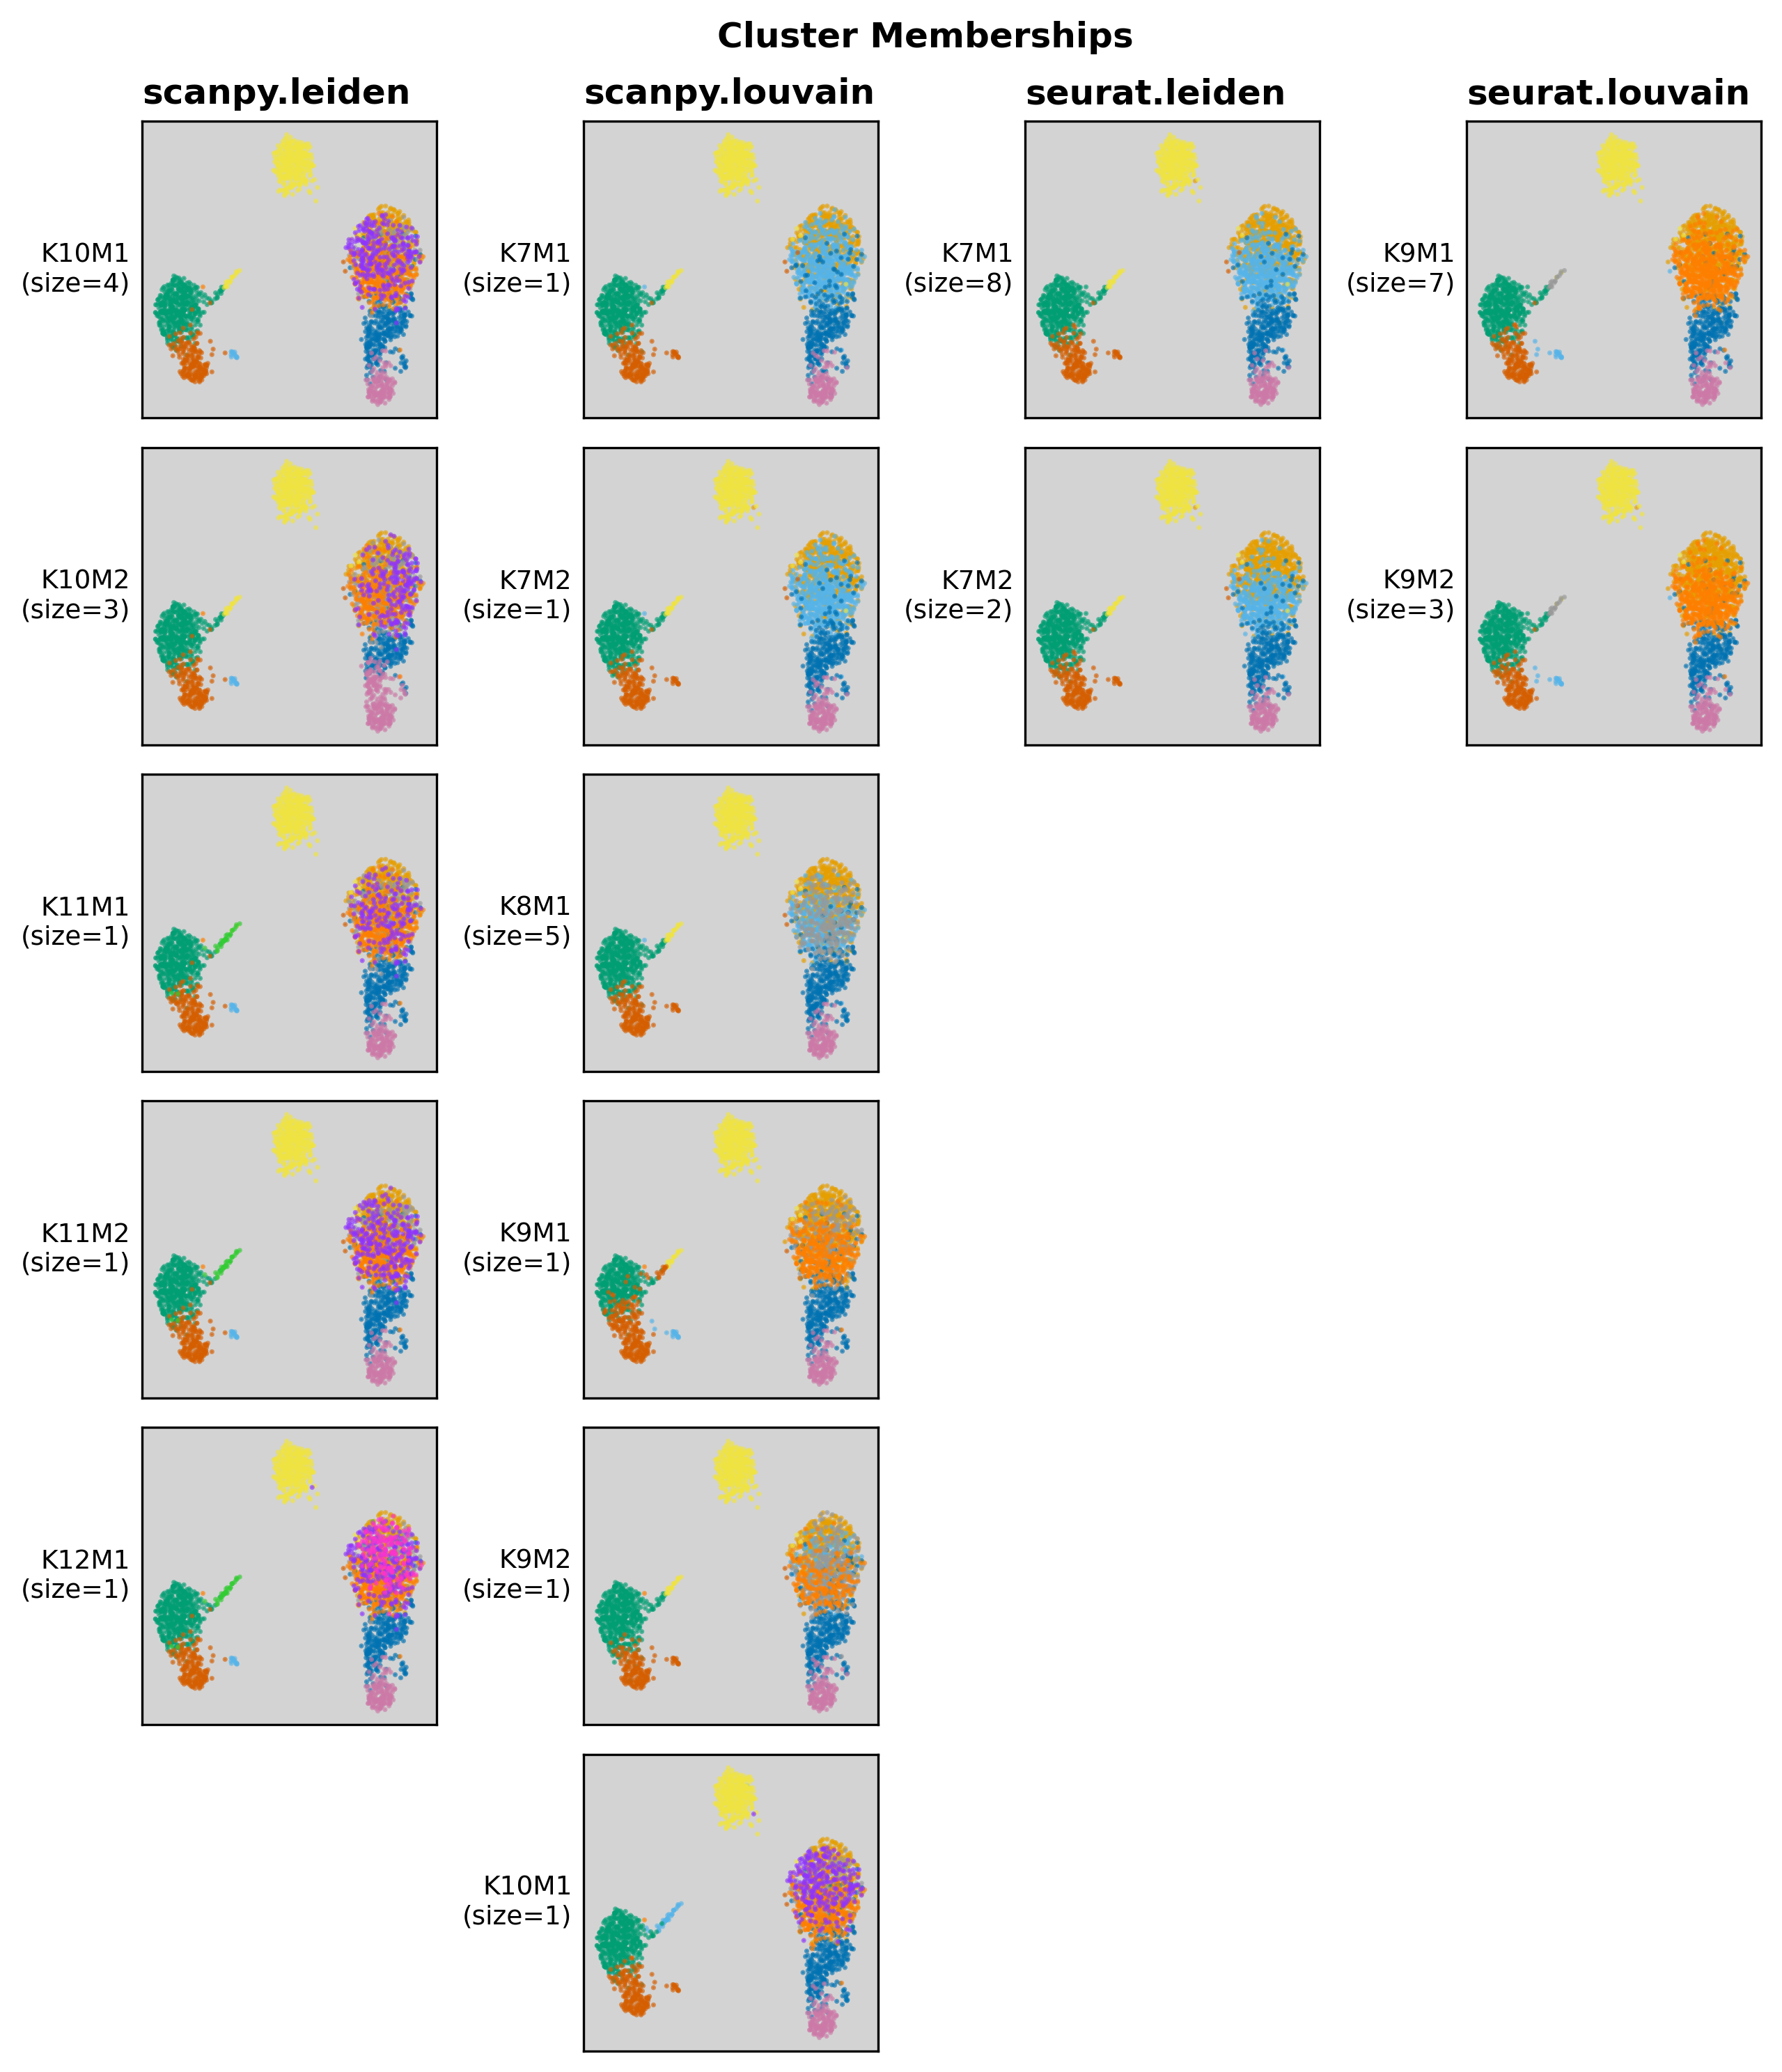

In [10]:
fig, ax = aoc.plot_compmodels_Q_grid(
    comp_res,
    X_umap, # coordinates for scatter plot
    colors=default_colors[:comp_res.K_max],
    val_threshold=0.5, # only plot points with membership values above this threshold
    suptitle="Cluster Memberships",
    y_suptitle=0.92,
    s=0.5,
    models_plot_order=['scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain'],
)

Difference in cluster memberships to a specific mode

Comparing to scanpy.tutorial_scanpy.tutorial


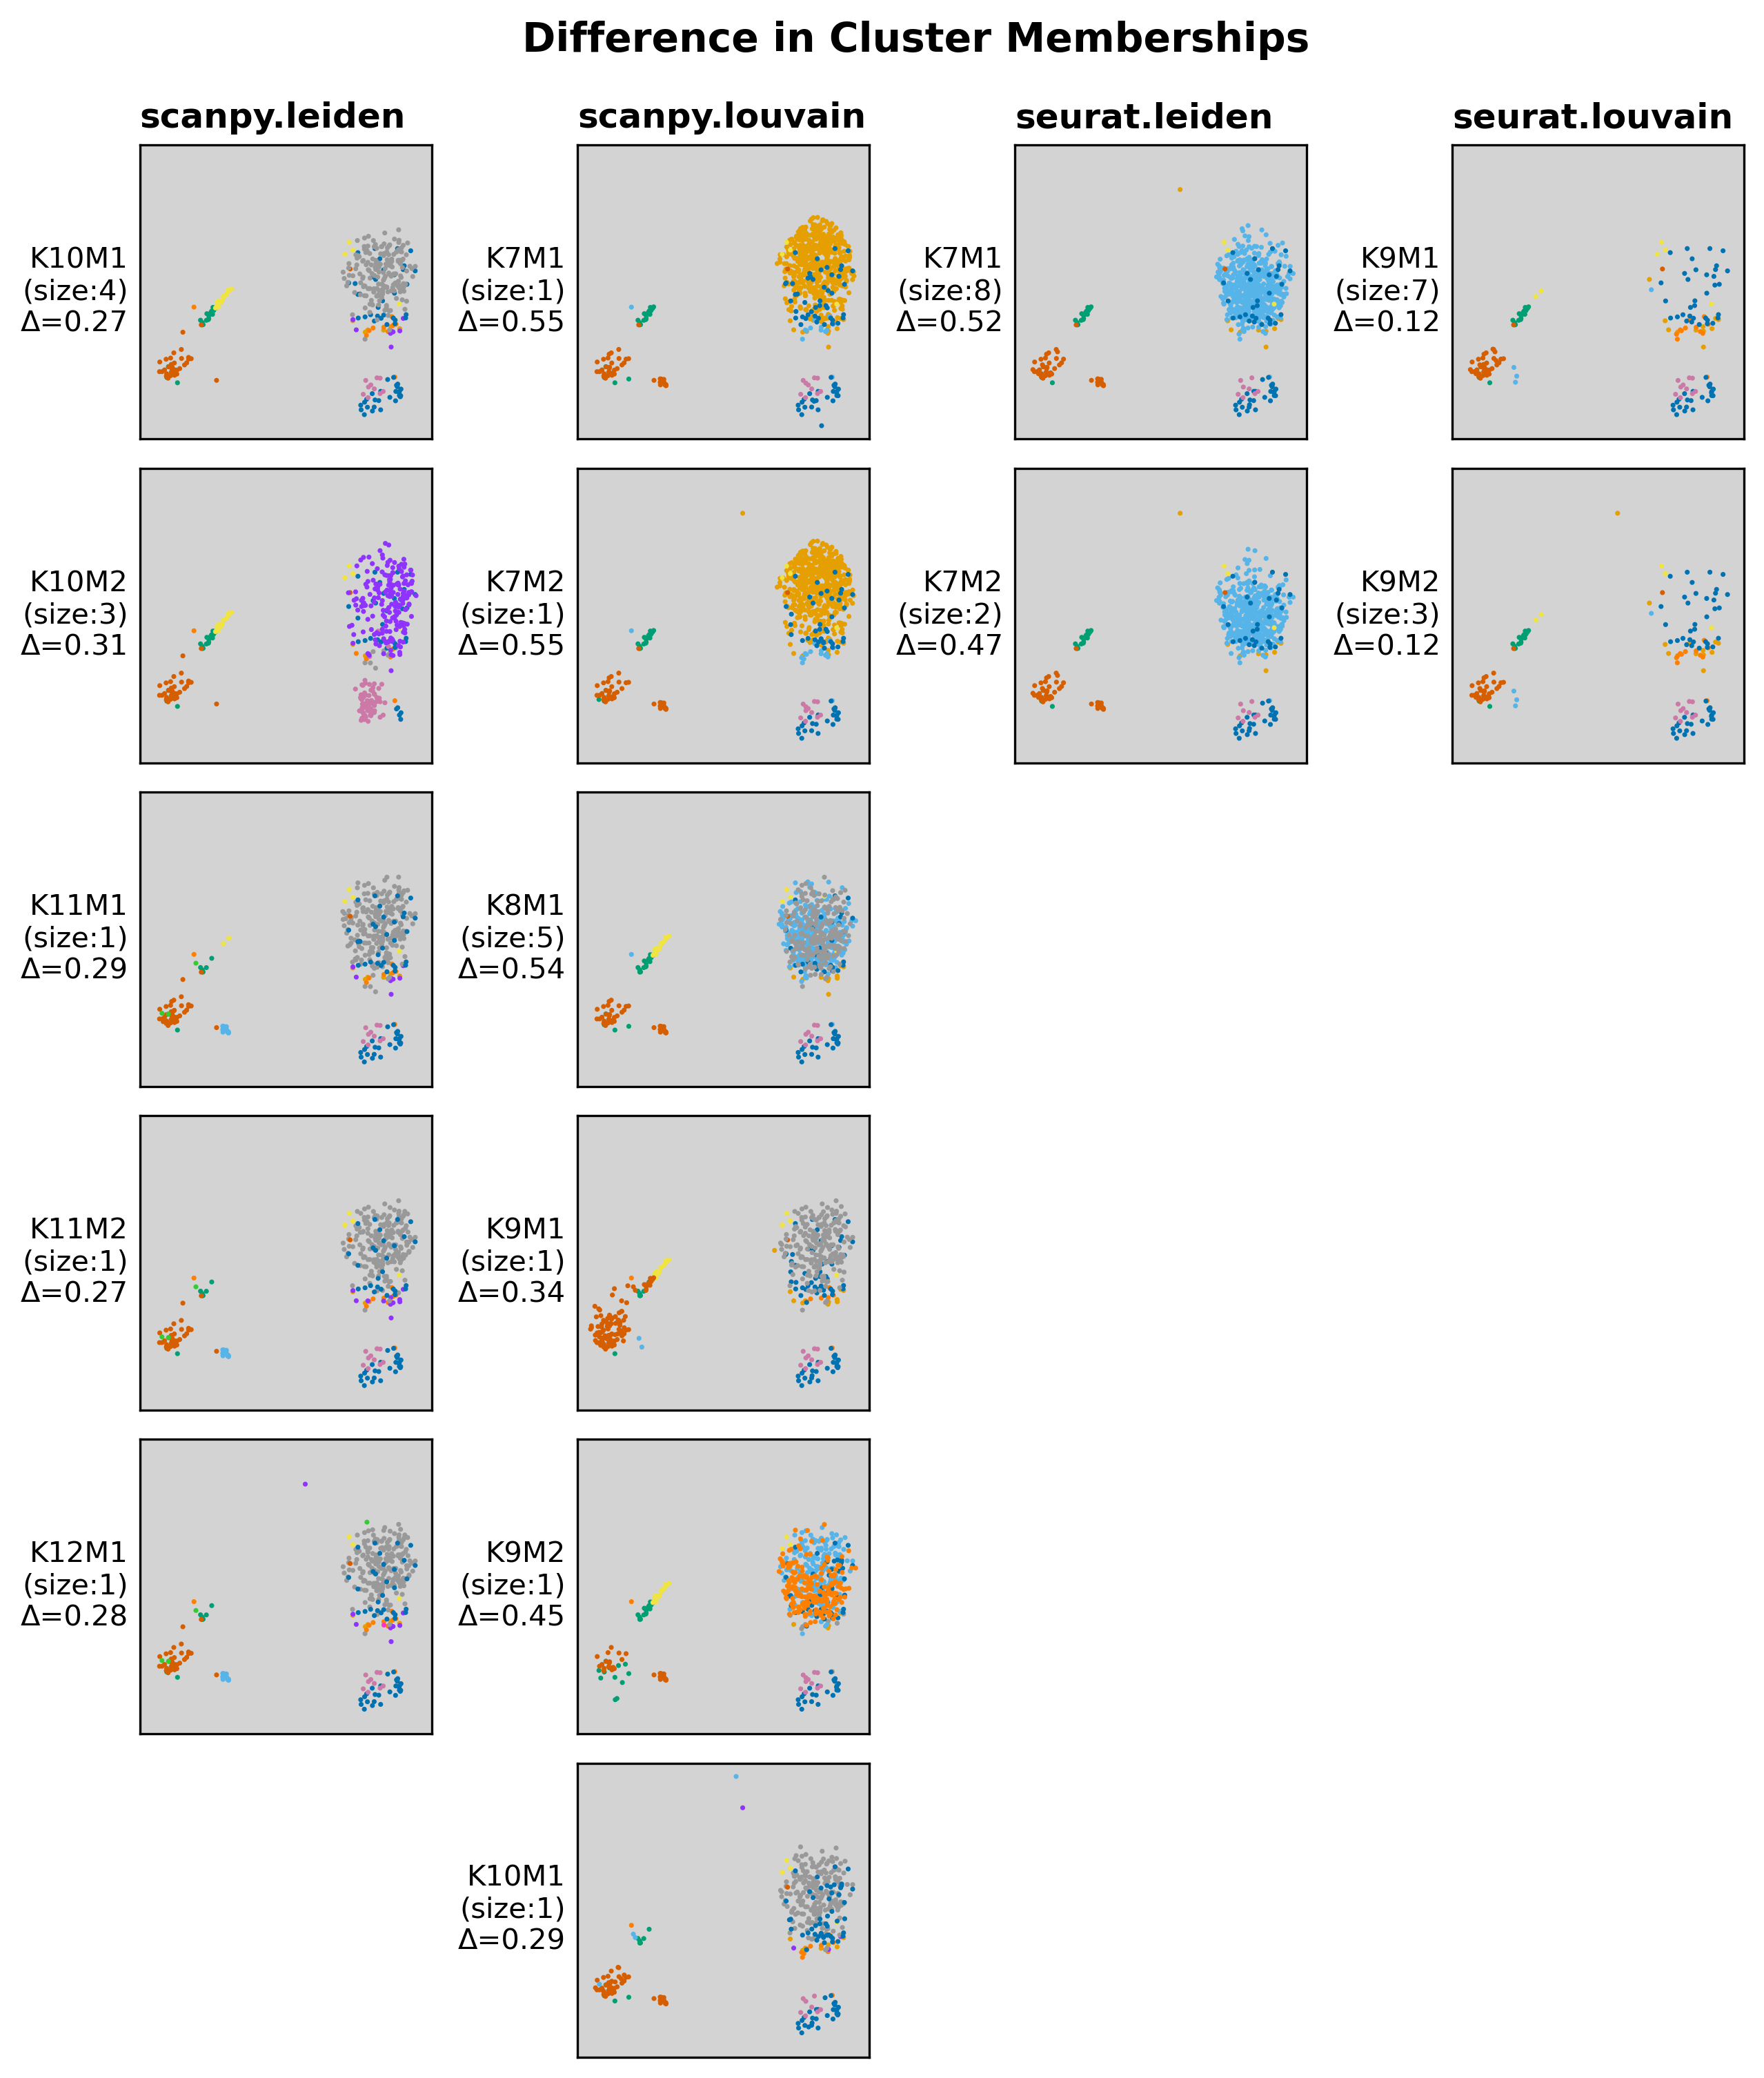

In [11]:
ref_mode = "scanpy.tutorial_scanpy.tutorial"
print(f"Comparing to {ref_mode}")

fig_diff, axes_diff = aoc.plot_compmodels_diff_grid(
    comp_res=comp_res,
    pair_mappings=pair_mappings,
    coords=X_umap,
    ref_mode=ref_mode, # the full name of the reference mode to compare to
    models_plot_order=['scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain'],
    diff_threshold=0.5, # only plot points with differences above this threshold
    val_threshold=0.1, # only plot points with reference membership values above this threshold
    colors=default_colors[:comp_res.K_max],
    s=0.5, alpha=0.9,  # point size and transparency
    suptitle="Difference in Cluster Memberships",
    y_suptitle=0.93,
)

#### Selected modes (e.g., major modes)
Cluster memberships

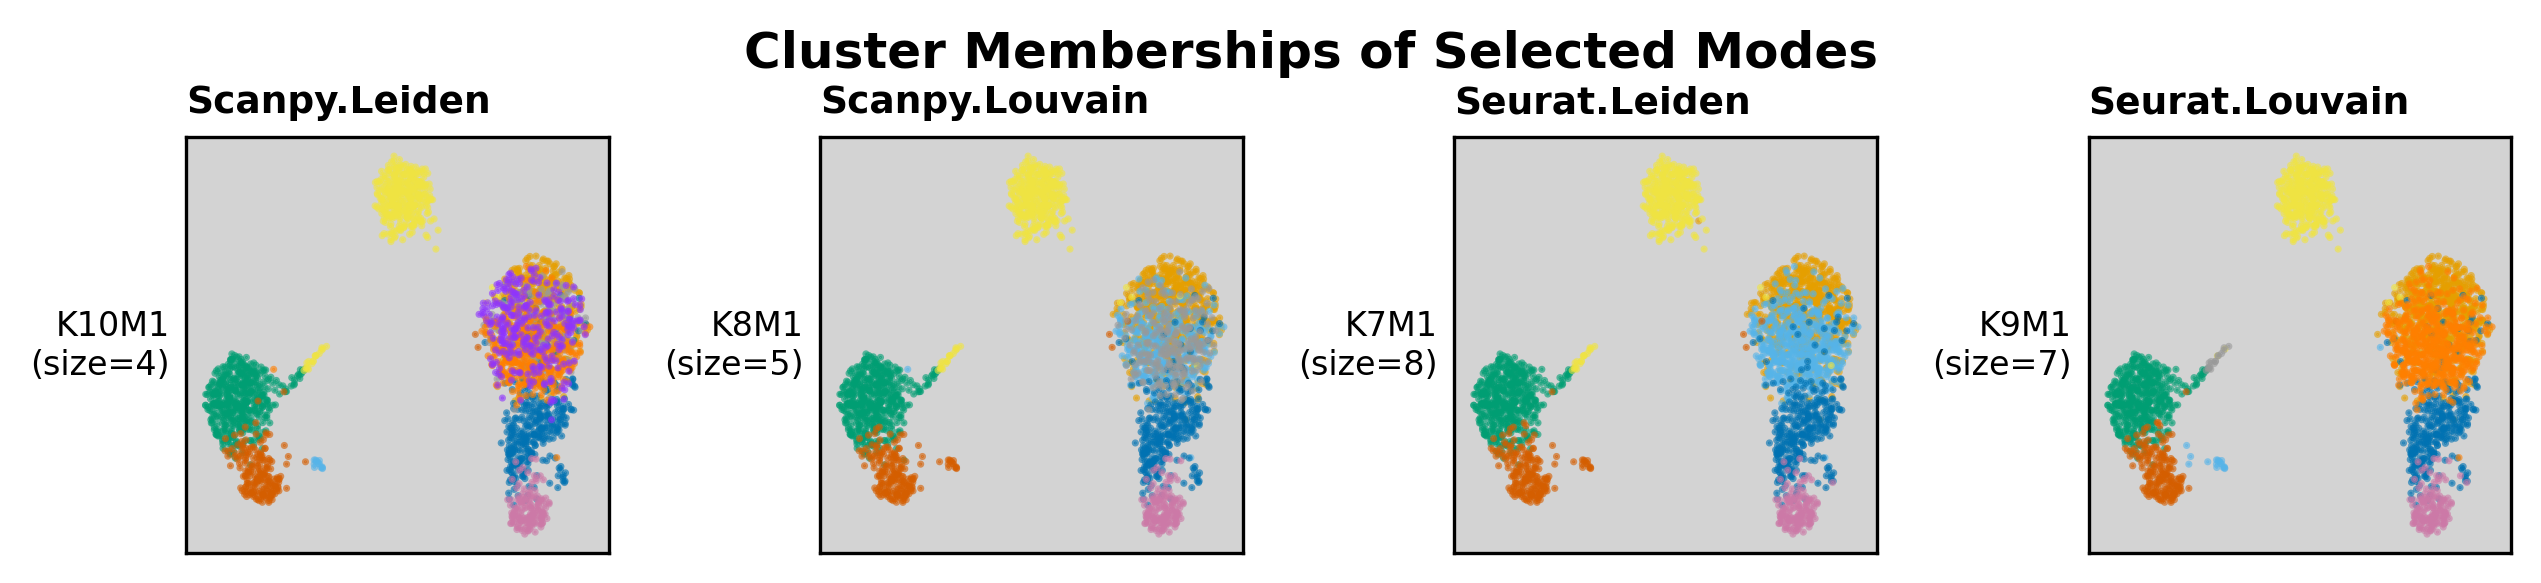

In [12]:
# get the major mode (with largest size) from each model
modes_to_plot = list()
for model in ['scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain']:
    major_mode = comp_res.mode_stats_by_model[model].sort_values(by='Size', ascending=False).index.values[0]
    modes_to_plot.append((model, major_mode))

fig, axes = aoc.plot_compmodels_Q_selected(
    comp_res,
    X_umap,
    model_mode_list=modes_to_plot,
    n_rows=1,          # number of rows in the plot grid
    colors=default_colors,  
    suptitle="Cluster Memberships of Selected Modes",
    y_suptitle=1.08,
    figsize_scale=(2.5,1.8),
    s=0.5,
)
# update individual titles
for model, mode in modes_to_plot:
    axes[(model, mode)].set_title(model.title(), fontsize=9, weight='bold', loc='left')

Difference in cluster memberships to a specific mode

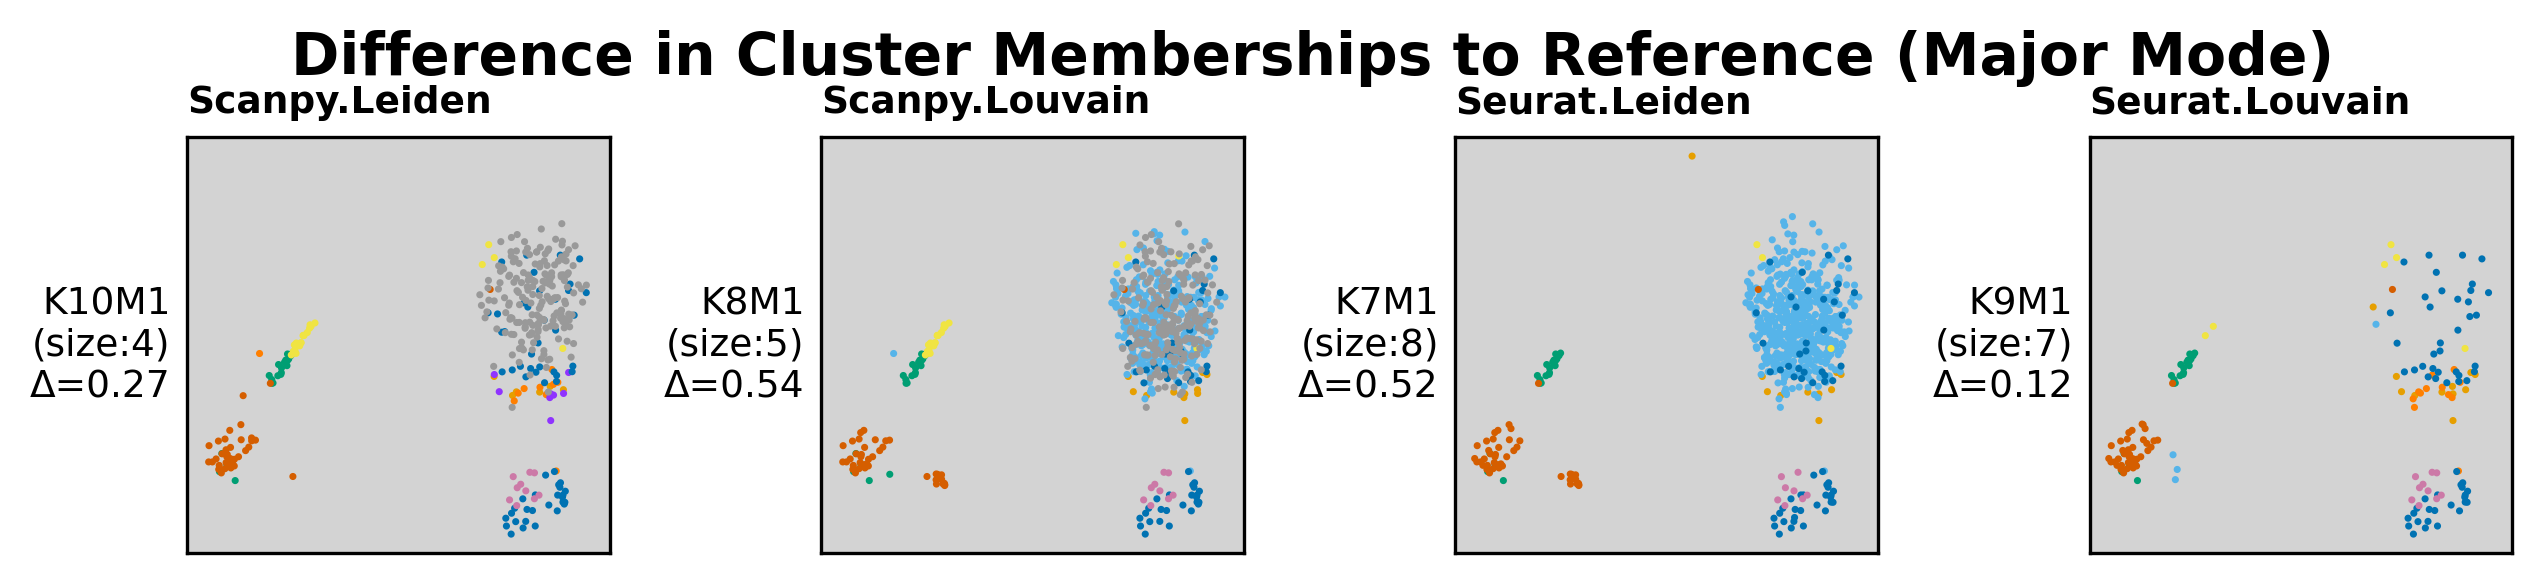

In [13]:
fig, axes = aoc.plot_compmodels_diff_selected(
    comp_res=comp_res,
    pair_mappings=pair_mappings,
    coords=X_umap,
    ref_mode=ref_mode,
    model_mode_list=modes_to_plot,
    n_rows=1,
    val_threshold=0.5,
    diff_threshold=0.1,
    s=0.5, alpha=0.9,
    colors=default_colors,  
    suptitle="Difference in Cluster Memberships to Reference (Major Mode)",
    y_suptitle=1.08,
    figsize_scale=(2.5,1.8),
)
# update individual titles
for model, mode in modes_to_plot:
    axes[(model, mode)].set_title(model.title(), fontsize=9, weight='bold', loc='left')


### Alignment

Text(378.91666666666663, 0.5, 'Modes')

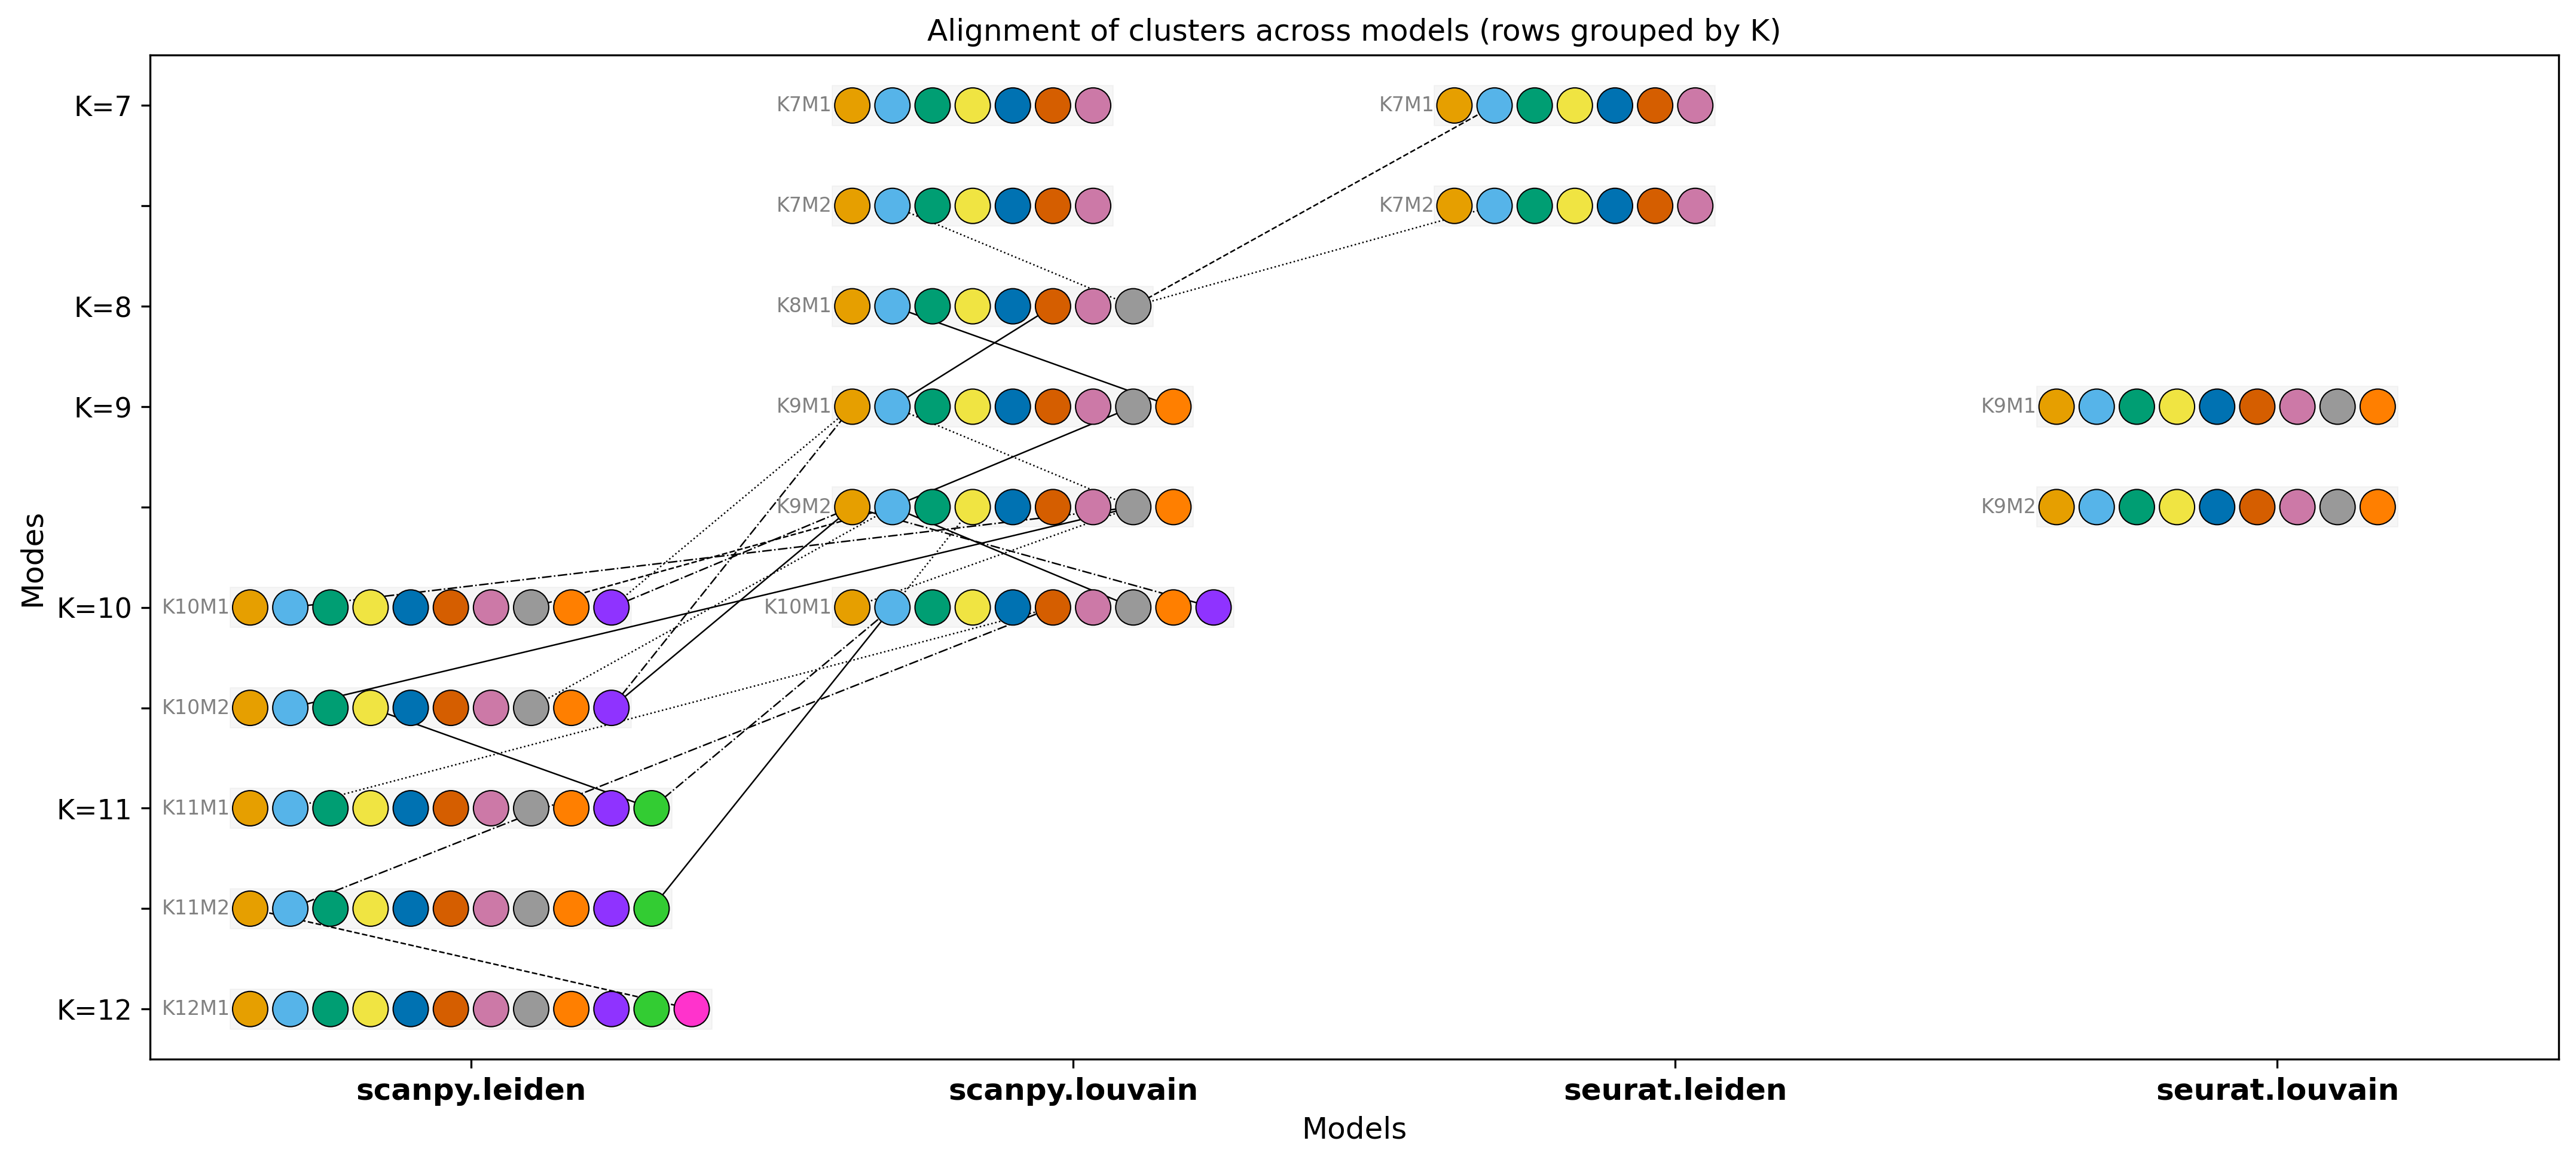

In [14]:
fig, ax = aoc.plot_compmodels_alignment_by_model(
    comp_res,
    cmap=default_colors[:comp_res.K_max],
    pair_mappings=pair_mappings,
    connect_identity=False,  # only highlight non-1–1 / shifted alignments
    adjacent_only=True,      # only between neighboring model columns
    label_modes=True,   # show mode names on the corner
    alt_ls=True, ls_alt=("-", "--", ":", "-."), lw=0.6, # line styles for different K
    figsize_scale=(0.3, 2.5),
    dpi=300,
    row_by_K=True, # put modes with same K in the same row
    models_plot_order=['scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain'],
)

# update y labels and titles
ax.set_yticklabels(['K=7', '', 'K=8', 'K=9', '', 'K=10', '', 'K=11', '', 'K=12'], fontsize=11)
ax.set_ylabel("Modes", fontsize=12)


### Structure plot of cluster memberships
First, reorder cells by a selected mode and get separation indices between cell clusters

In [15]:
# reordering of individuals based on scanpy.leiden_K12M1
cell_reorder_ref_mode = "scanpy.leiden_K12M1"
pseudo_gt_lbs = np.argmax(comp_res.Q_by_mode[cell_reorder_ref_mode],axis=1)
cell_reorder_idx = np.hstack([np.where(pseudo_gt_lbs==k)[0] for k in np.unique(pseudo_gt_lbs)])
grps = pseudo_gt_lbs[cell_reorder_idx]
grp_lbs, grp_indices, grp_seps = get_uniq_lb_sep(grps)

Next, get a list of modes to plot, and assign them labels to be included on the y-axis.

In [16]:
modes_to_plot = list()
modes_labels = list()

for model in ['scanpy.tutorial', 'scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain']:
    # get mode with largest size
    modes = comp_res.modes_by_model[model]
    modes_to_plot.extend([f"{model}_{mode}" for mode in modes])
    if model=='scanpy.tutorial':
        modes_labels.append(f"Scanpy Tutorial [Reference]\n(K={refQ.shape[1]})")
    else:
        for i_mode,mode in enumerate(modes):
            size = comp_res.mode_stats_by_model[model].loc[mode]['Size']
            if i_mode==0:
                lb = f"{model.title()} {mode}\n(K={size})"
            else:
                lb = f"{mode}\n(size={size})"
            modes_labels.append(lb)


Finally, generate a structure plot for each mode, reordering cells so that those sharing the same cluster label in the selected mode are grouped together.

*Note: This visualization can be time-consuming to generate. If your notebook is memory-limited, please skip this step.*

In [ ]:
fig = plt.figure(figsize=(9,len(modes_to_plot)*0.7), dpi=150)
gs = fig.add_gridspec(len(modes_to_plot)+1, 1, width_ratios=[1])

for i, mode_full_name in enumerate(modes_to_plot):
    ax_membership = fig.add_subplot(gs[i])
    # get aligned Q matrix for the mode
    alignedQ = comp_res.Q_by_mode[mode_full_name][cell_reorder_idx,:]
    
    # plot membership as stacked barplot (structure plot)
    plot_membership(alignedQ, default_colors, ax=ax_membership, ylab="", title="", fontsize=14)
    # use the mode full name as y label
    ax_membership.set_ylabel(mode_full_name, fontsize=10, weight='bold', rotation=0, ha='right', va='center')
    # # use the prepared labels instead
    # ax_membership.set_ylabel(modes_labels[i], fontsize=10, weight='bold', rotation=0, ha='right', va='center')
    
    # add vertical lines to separate groups based on the cell-reorder reference  mode
    for v in grp_seps:
        ax_membership.axvline(v, ymin=-1.5, ymax=1, color='darkgray', ls='--', lw=0.3, clip_on=False)
    if i==len(modes_to_plot)-1:
        for v in grp_seps:
            ax_membership.set_xticks(grp_indices)
            ax_membership.set_xticklabels(np.arange(len(grp_lbs))+1, fontsize=9, rotation=0)
            ax_membership.tick_params(axis='x', length=0)  
    
fig.tight_layout()


#### Difference in cluster memberships

Compute difference matrices against reference mode

In [ ]:
mat_diffs = aoc.get_diff_matrices(
    comp_res,
    pair_mappings,
    ref_mode=ref_mode,
    strict_pair_mapping=True,
)

Plot difference in cluster memberships for selected modes

In [ ]:
# reordering of individuals based on scanpy.leiden_K10M1
maxK_mode = "scanpy.leiden_K10M1"
pseudo_gt_lbs = np.argmax(comp_res.Q_by_mode[maxK_mode],axis=1)
cell_reorder_idx = np.hstack([np.where(pseudo_gt_lbs==k)[0] for k in np.unique(pseudo_gt_lbs)])
grps = pseudo_gt_lbs[cell_reorder_idx]
grp_lbs, grp_indices, grp_seps = get_uniq_lb_sep(grps)

In [ ]:
modes_to_plot = list()
modes_labels = list()

for model in ['scanpy.leiden','scanpy.louvain','seurat.leiden','seurat.louvain']:
    major_mode = comp_res.mode_stats_by_model[model].sort_values(by='Size', ascending=False).index.values[0]
    modes_to_plot.append(f"{model}_{major_mode}")
    size = comp_res.mode_stats_by_model[model].loc[major_mode]['Size']
    lb = f"{model.title()}\n{major_mode} (K={size})"
    modes_labels.append(lb)

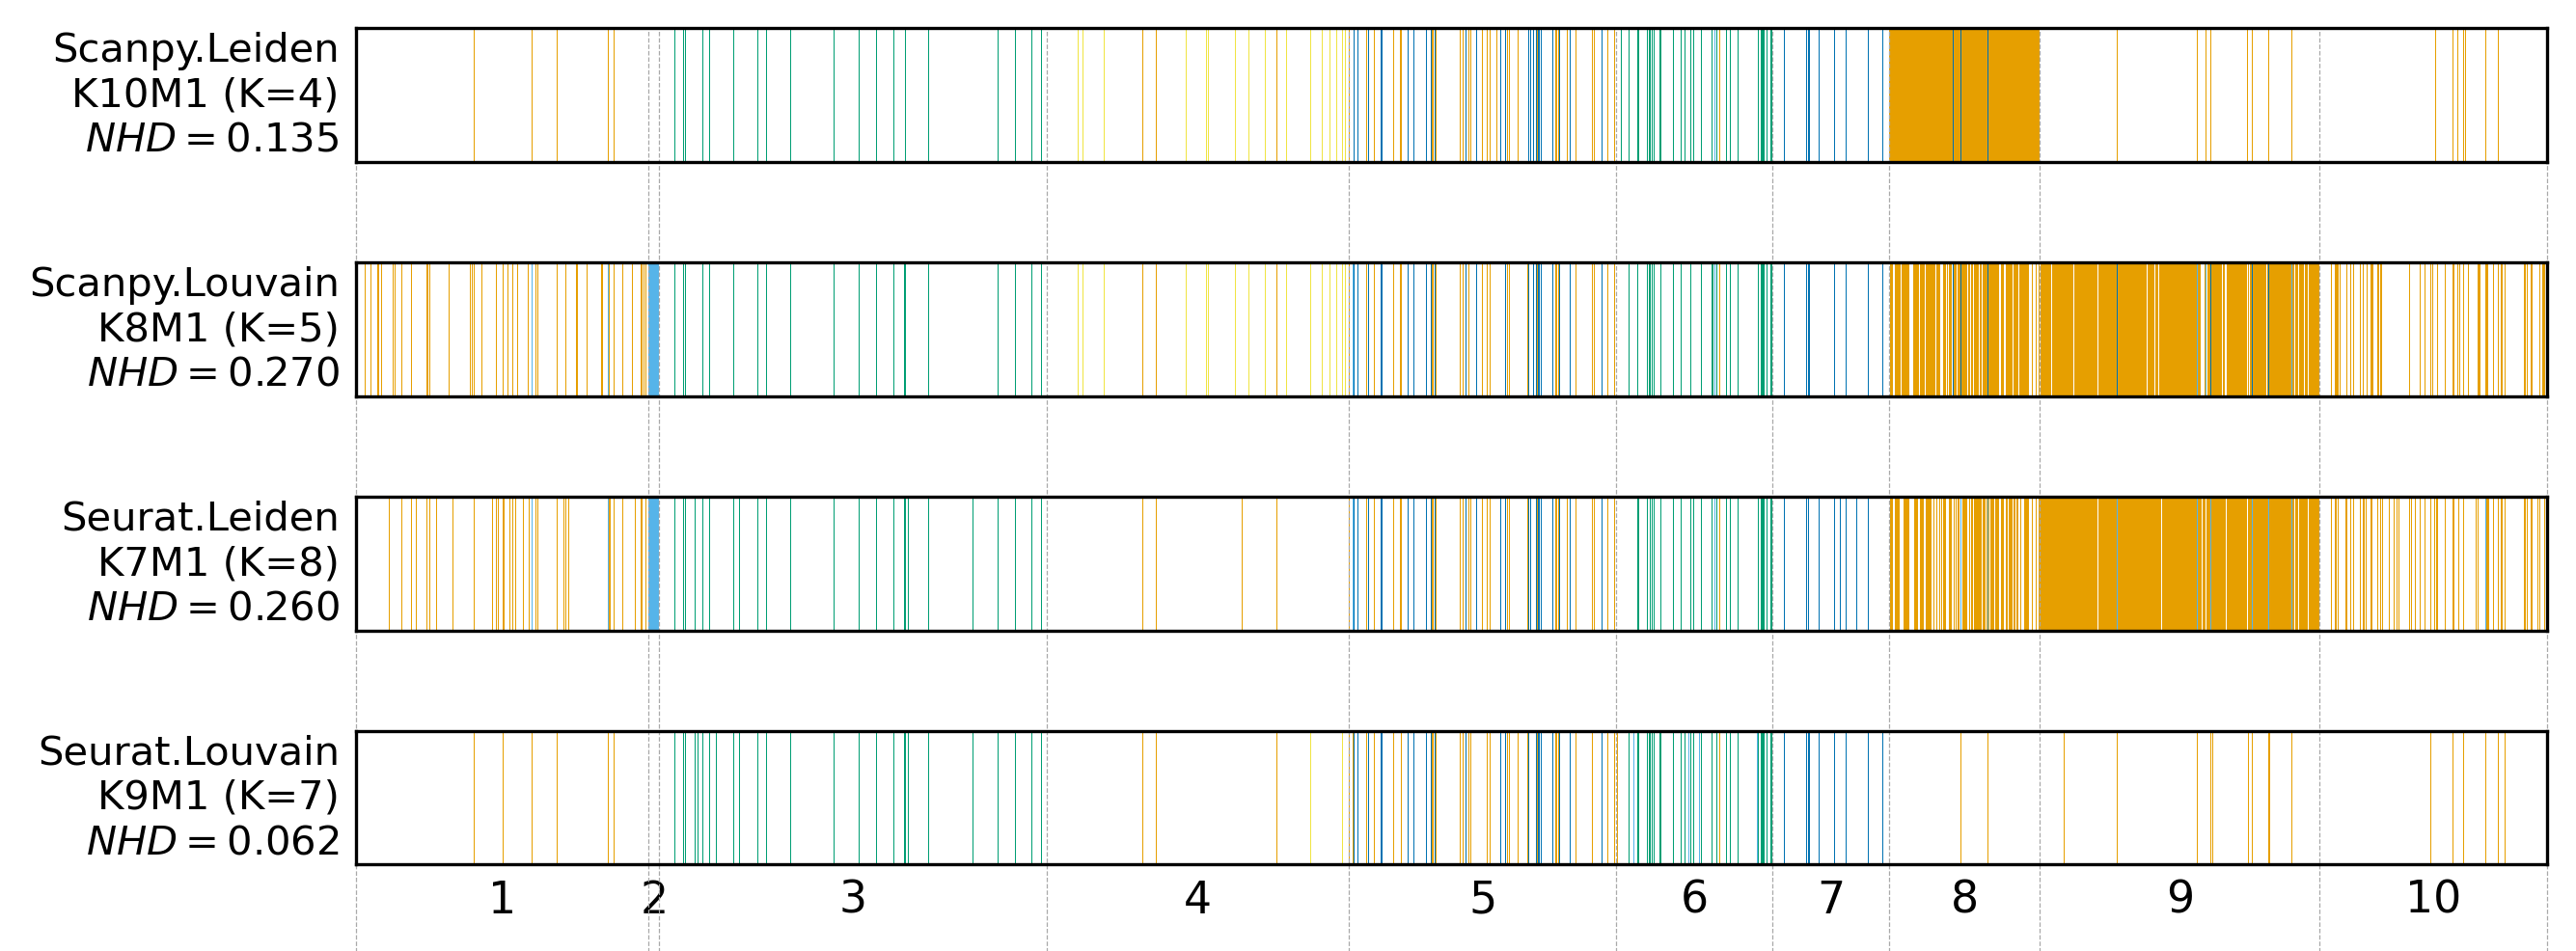

In [ ]:
fig = plt.figure(figsize=(9,len(modes_to_plot)), dpi=300)
gs = fig.add_gridspec(len(modes_to_plot)+1, 1, width_ratios=[1])

for i, mode_full_name in enumerate(modes_to_plot):

    ax_diff = fig.add_subplot(gs[i])
    # get difference Q matrix for the mode
    diffQ = mat_diffs[mode_full_name.split("_")[0]][mode_full_name.split("_")[1]][cell_reorder_idx,:]
    # calculate normalized Hamming distance (NHD)
    nhd = np.sum(np.sum(diffQ, axis=1)>1e-6)/diffQ.shape[0]
    # plot difference membership as stacked barplot (structure plot)
    plot_membership(diffQ, default_colors, ax=ax_diff, ylab="", title="", fontsize=14)
    # # use the mode full name as y label
    # ax_diff.set_ylabel(mode_full_name, fontsize=10, weight='bold', rotation=0, ha='right', va='center')
    # use the prepared labels instead
    ax_diff.set_ylabel(modes_labels[i]+"\n$NHD={:.3f}$".format(nhd), fontsize=10, rotation=0, ha='right', va='center')

    # add vertical lines to separate groups based on cell-reorder reference mode
    for v in grp_seps:
        ax_diff.axvline(v, ymin=-1.5, ymax=1, color='darkgray', ls='--', lw=0.3, clip_on=False)
    if i==len(modes_to_plot)-1:
        for v in grp_seps:
            ax_diff.set_xticks(grp_indices)
            ax_diff.set_xticklabels(np.arange(len(grp_lbs))+1, fontsize=11, rotation=0)
            ax_diff.tick_params(axis='x', length=0)  
    
fig.tight_layout()